# Deteksi URL Phishing dengan LSTM

In [ ]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
import json
import re
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve,
)

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
PROJECT_DIR = Path(
    "/content/drive/MyDrive/phishing_lstm_project"
)

ZIP_FILE = (
    PROJECT_DIR
    / "phishing_clean_dataset_package.zip"
)

CLEAN_DIR = PROJECT_DIR / "clean_data"
MODEL_DIR = PROJECT_DIR / "model_pure_lstm"
OUTPUT_DIR = PROJECT_DIR / "output_pure_lstm"

CLEAN_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_FILE = CLEAN_DIR / "train_clean_2columns.csv.gz"
VAL_FILE = CLEAN_DIR / "validation_clean_2columns.csv.gz"
TEST_FILE = CLEAN_DIR / "test_clean_2columns.csv.gz"
EXTERNAL_FILE = CLEAN_DIR / "external_phishtank_clean.csv.gz"

MODEL_PATH = MODEL_DIR / "pure_lstm_best.keras"
THRESHOLD_PATH = MODEL_DIR / "thresholds.json"
METRICS_PATH = MODEL_DIR / "internal_test_metrics.json"
EXTERNAL_METRICS_PATH = MODEL_DIR / "external_test_metrics.json"
HISTORY_PATH = MODEL_DIR / "training_history.csv"

required_files = [
    TRAIN_FILE,
    VAL_FILE,
    TEST_FILE,
    EXTERNAL_FILE,
]

if not all(path.exists() for path in required_files):
    if not ZIP_FILE.exists():
        raise FileNotFoundError(
            f"Paket dataset tidak ditemukan:\n{ZIP_FILE}\n\n"
            "Upload phishing_clean_dataset_package.zip "
            "ke folder phishing_lstm_project di Google Drive."
        )

    print("Mengekstrak dataset bersih...")

    with zipfile.ZipFile(
        ZIP_FILE,
        "r"
    ) as zip_file:
        zip_file.extractall(CLEAN_DIR)

for path in required_files:
    if not path.exists():
        raise FileNotFoundError(
            f"File hasil ekstraksi tidak ditemukan: {path}"
        )

print("Semua dataset ditemukan.")


Mengekstrak dataset bersih...
Semua dataset ditemukan.


## 1. Memuat dataset bersih

Label:

- `0` = legitimate
- `1` = phishing

Train, validation, dan test sebelumnya sudah dipisahkan berdasarkan hostname sehingga hostname yang sama tidak tersebar ke subset berbeda.


In [ ]:
train_df = pd.read_csv(
    TRAIN_FILE,
    low_memory=False
)

val_df = pd.read_csv(
    VAL_FILE,
    low_memory=False
)

test_df = pd.read_csv(
    TEST_FILE,
    low_memory=False
)

external_df = pd.read_csv(
    EXTERNAL_FILE,
    low_memory=False
)

def validate_dataset(name, frame):
    required_columns = {"url", "label"}

    if not required_columns.issubset(frame.columns):
        raise ValueError(
            f"{name} harus mempunyai kolom {required_columns}"
        )

    frame = frame.dropna(
        subset=["url", "label"]
    ).copy()

    frame["url"] = (
        frame["url"]
        .astype(str)
        .str.strip()
    )

    frame["label"] = pd.to_numeric(
        frame["label"],
        errors="coerce"
    )

    frame = frame[
        frame["url"].ne("")
        & frame["label"].isin([0, 1])
    ].copy()

    frame["label"] = frame["label"].astype("int8")

    return frame.reset_index(drop=True)

train_df = validate_dataset("Train", train_df)
val_df = validate_dataset("Validation", val_df)
test_df = validate_dataset("Test", test_df)
external_df = validate_dataset(
    "External PhishTank",
    external_df
)

def show_dataset(name, frame):
    print(
        f"{name:<20} "
        f"rows={len(frame):>8,} | "
        f"legitimate={(frame['label'] == 0).sum():>8,} | "
        f"phishing={(frame['label'] == 1).sum():>8,}"
    )

show_dataset("Train", train_df)
show_dataset("Validation", val_df)
show_dataset("Internal test", test_df)
show_dataset("External PhishTank", external_df)


Train                rows= 255,282 | legitimate= 179,006 | phishing=  76,276
Validation           rows=  32,097 | legitimate=  22,635 | phishing=   9,462
Internal test        rows=  32,021 | legitimate=  22,368 | phishing=   9,653
External PhishTank   rows=  10,000 | legitimate=       0 | phishing=  10,000


## 2. Analisis distribusi data


,dataset,rows,legitimate,phishing,mean_length,median_length,p90_length,p95_length,p99_length,max_length
0,train,255282,179006,76276,49.561783,40.0,88.0,113.0,210.00,2175
1,validation,32097,22635,9462,49.728510,40.0,88.0,113.0,207.00,974
2,test,32021,22368,9653,49.184660,39.0,87.0,112.0,207.00,2307
3,external_phishtank,10000,0,10000,40.820700,33.0,60.0,86.0,223.01,3061


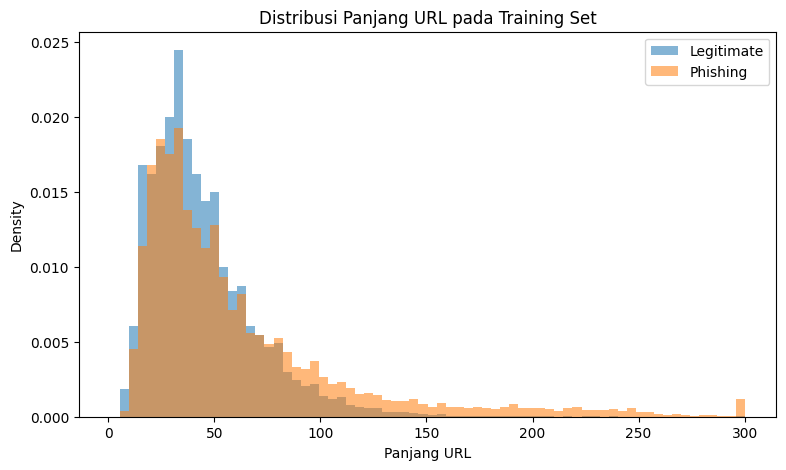

In [ ]:
summary_rows = []

for name, frame in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df),
    ("external_phishtank", external_df),
]:
    lengths = frame["url"].str.len()

    summary_rows.append({
        "dataset": name,
        "rows": len(frame),
        "legitimate": int(
            (frame["label"] == 0).sum()
        ),
        "phishing": int(
            (frame["label"] == 1).sum()
        ),
        "mean_length": float(lengths.mean()),
        "median_length": float(lengths.median()),
        "p90_length": float(lengths.quantile(0.90)),
        "p95_length": float(lengths.quantile(0.95)),
        "p99_length": float(lengths.quantile(0.99)),
        "max_length": int(lengths.max()),
    })

data_summary = pd.DataFrame(summary_rows)
display(data_summary)

data_summary.to_csv(
    OUTPUT_DIR / "dataset_summary.csv",
    index=False
)

plt.figure(figsize=(9, 5))

for label, label_name in [
    (0, "Legitimate"),
    (1, "Phishing"),
]:
    values = (
        train_df.loc[
            train_df["label"] == label,
            "url"
        ]
        .str.len()
        .clip(upper=300)
    )

    plt.hist(
        values,
        bins=70,
        alpha=0.55,
        density=True,
        label=label_name
    )

plt.xlabel("Panjang URL")
plt.ylabel("Density")
plt.title("Distribusi Panjang URL pada Training Set")
plt.legend()
plt.show()


## 3. Membuat TensorFlow Dataset

Model membaca URL sebagai teks. URL kemudian dipecah menjadi urutan karakter.


In [ ]:
BATCH_SIZE = 256
MAX_TOKENS = 300

p99_length = int(
    train_df["url"]
    .str.len()
    .quantile(0.99)
)

MAX_LEN = min(
    max(p99_length, 100),
    180
)

print("Panjang persentil 99:", p99_length)
print("MAX_LEN:", MAX_LEN)

AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(frame, training=False):
    urls = frame["url"].astype(str).to_numpy()
    labels = (
        frame["label"]
        .astype("float32")
        .to_numpy()
    )

    dataset = tf.data.Dataset.from_tensor_slices(
        (urls, labels)
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=min(
                len(frame),
                100_000
            ),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    return (
        dataset
        .batch(BATCH_SIZE)
        .prefetch(AUTOTUNE)
    )

train_ds = make_dataset(
    train_df,
    training=True
)

val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)
external_ds = make_dataset(external_df)


Panjang persentil 99: 210
MAX_LEN: 180


In [ ]:
vectorizer = tf.keras.layers.TextVectorization(
    standardize=None,
    split="character",
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=MAX_LEN,
    name="character_vectorizer"
)

adapt_dataset = (
    tf.data.Dataset
    .from_tensor_slices(
        train_df["url"]
        .astype(str)
        .to_numpy()
    )
    .batch(4096)
)

vectorizer.adapt(adapt_dataset)

vocabulary = vectorizer.get_vocabulary()
VOCAB_SIZE = len(vocabulary)

print("Vocabulary size:", VOCAB_SIZE)
print("Contoh vocabulary:", vocabulary[:40])


Vocabulary size: 194
Contoh vocabulary: ['', '[UNK]', np.str_('e'), np.str_('o'), np.str_('a'), np.str_('t'), np.str_('i'), np.str_('s'), np.str_('c'), np.str_('n'), np.str_('.'), np.str_('r'), np.str_('/'), np.str_('m'), np.str_('l'), np.str_('d'), np.str_('p'), np.str_('h'), np.str_('-'), np.str_('u'), np.str_('w'), np.str_('g'), np.str_('b'), np.str_('f'), np.str_('1'), np.str_('0'), np.str_('y'), np.str_('2'), np.str_('k'), np.str_('v'), np.str_('3'), np.str_('4'), np.str_('8'), np.str_('5'), np.str_('6'), np.str_('9'), np.str_('7'), np.str_('x'), np.str_('_'), np.str_('=')]


## Arsitektur:

```text
URL
→ Character Vectorization
→ Embedding
→ SpatialDropout1D
→ LSTM
→ Dense
→ Dropout
→ Sigmoid
```



In [ ]:
from tensorflow.keras import regularizers

EMBEDDING_DIM = 24
LSTM_UNITS = 32

url_input = tf.keras.Input(
    shape=(),
    dtype=tf.string,
    name="url"
)

x = vectorizer(url_input)

x = tf.keras.layers.Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    mask_zero=True,
    embeddings_regularizer=regularizers.l2(1e-6),
    name="character_embedding"
)(x)

x = tf.keras.layers.SpatialDropout1D(
    rate=0.35,
    name="spatial_dropout"
)(x)

x = tf.keras.layers.LSTM(
    units=LSTM_UNITS,
    return_sequences=False,
    dropout=0.25,
    recurrent_dropout=0.0,
    kernel_regularizer=regularizers.l2(1e-5),
    recurrent_regularizer=regularizers.l2(1e-5),
    name="lstm"
)(x)

x = tf.keras.layers.Dense(
    units=16,
    activation="relu",
    kernel_regularizer=regularizers.l2(2e-4),
    name="dense"
)(x)

x = tf.keras.layers.Dropout(
    rate=0.50,
    name="final_dropout"
)(x)

output = tf.keras.layers.Dense(
    units=1,
    activation="sigmoid",
    dtype="float32",
    name="phishing_probability"
)(x)

model = tf.keras.Model(
    inputs=url_input,
    outputs=output,
    name="pure_character_lstm"
)

try:
    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=3e-4,
        weight_decay=1e-4,
        clipnorm=1.0
    )
except AttributeError:
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=3e-4,
        clipnorm=1.0
    )

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.BinaryCrossentropy(
        label_smoothing=0.02
    ),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),
        tf.keras.metrics.Precision(
            name="precision"
        ),
        tf.keras.metrics.Recall(
            name="recall"
        ),
        tf.keras.metrics.AUC(
            name="roc_auc",
            curve="ROC"
        ),
        tf.keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        ),
    ]
)

model.summary()


Model: "pure_character_lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ url (InputLayer)    │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ character_vectoriz… │ (None, 180)       │          0 │ url[0][0]         │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ character_embedding │ (None, 180, 24)   │      4,656 │ character_vector… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout     │ (None, 180, 24)   │          0 │ character_embedd… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 180)       │          0 │ character_vector… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 32)        │      7,296 │ spatial_dropout[… │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │        528 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ final_dropout       │ (None, 16)        │          0 │ dense[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ phishing_probabili… │ (None, 1)         │         17 │ final_dropout[0]… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,497 (48.82 KB)

 Trainable params: 12,497 (48.82 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Class weight

Class weight digunakan karena jumlah legitimate dan phishing tidak seimbang.


In [ ]:
classes = np.array([0, 1])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].to_numpy()
)

class_weight = {
    0: float(weights[0]),
    1: float(weights[1]),
}

print("Class weight:", class_weight)


Class weight: {0: 0.7130543110286806, 1: 1.6734097225863969}


## 6. Training dengan pengendalian overfitting

Model terbaik dipilih berdasarkan nilai `val_loss` terendah.


In [ ]:
# 10. Callback
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(MODEL_PATH),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=2,
        min_delta=1e-3,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=1,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.TerminateOnNaN(),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

history_df = pd.DataFrame(
    history.history
)

history_df.to_csv(
    HISTORY_PATH,
    index=False
)

print("Model terbaik tersimpan:", MODEL_PATH)
print("Riwayat training:", HISTORY_PATH)


Epoch 1/15
997/998 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6944 - loss: 0.5927 - pr_auc: 0.6135 - precision: 0.4941 - recall: 0.6926 - roc_auc: 0.7540
Epoch 1: val_loss improved from None to 0.44249, saving model to /content/drive/MyDrive/phishing_lstm_project/model_pure_lstm/pure_lstm_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/phishing_lstm_project/model_pure_lstm/pure_lstm_best.keras
998/998 ━━━━━━━━━━━━━━━━━━━━ 31s 24ms/step - accuracy: 0.7585 - loss: 0.5402 - pr_auc: 0.7135 - precision: 0.5759 - recall: 0.7267 - roc_auc: 0.8183 - val_accuracy: 0.8209 - val_loss: 0.4425 - val_pr_auc: 0.7984 - val_precision: 0.6840 - val_recall: 0.7295 - val_roc_auc: 0.8774 - learning_rate: 3.0000e-04
Epoch 2/15
996/998 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8091 - loss: 0.4774 - pr_auc: 0.7714 - precision: 0.6477 - recall: 0.7580 - roc_auc: 0.8631
Epoch 2: val_loss improved from 0.44249 to 0.42330, saving model to /content/drive/MyDrive/phishing_lstm_projec

## 7. Memeriksa kurva training

Overfitting klasik ditandai oleh `train_loss` yang terus turun ketika `val_loss` mulai naik.


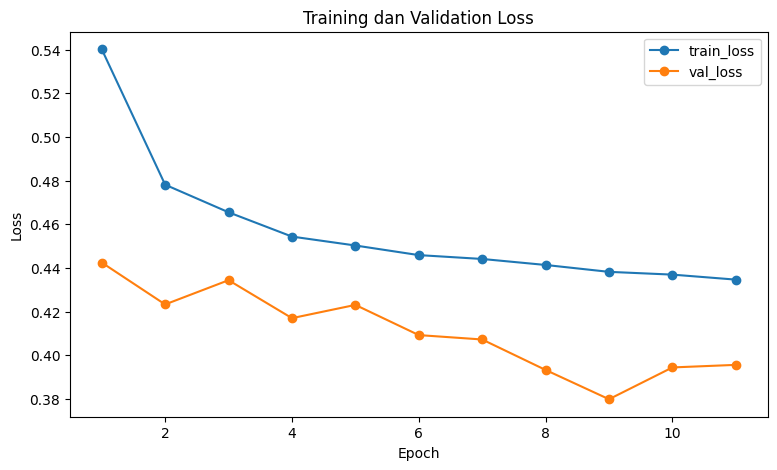

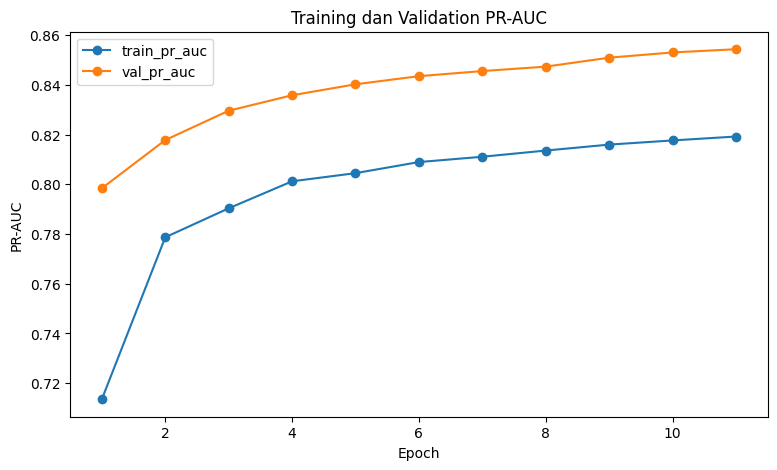

Best epoch berdasarkan val_loss: 9


In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_df.index + 1,
    history_df["loss"],
    marker="o",
    label="train_loss"
)

plt.plot(
    history_df.index + 1,
    history_df["val_loss"],
    marker="o",
    label="val_loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training dan Validation Loss")
plt.legend()
plt.show()

# Kurva PR-AUC
plt.figure(figsize=(9, 5))

plt.plot(
    history_df.index + 1,
    history_df["pr_auc"],
    marker="o",
    label="train_pr_auc"
)

plt.plot(
    history_df.index + 1,
    history_df["val_pr_auc"],
    marker="o",
    label="val_pr_auc"
)

plt.xlabel("Epoch")
plt.ylabel("PR-AUC")
plt.title("Training dan Validation PR-AUC")
plt.legend()
plt.show()

best_epoch = int(
    history_df["val_loss"].idxmin() + 1
)

print("Best epoch berdasarkan val_loss:", best_epoch)


## 8. Menentukan threshold

Dibuat dua threshold:

- `balanced_threshold`: F1 validation tertinggi;
- `strict_threshold`: false positive rate validation maksimal 1%.

Untuk prediksi URL baru, strict threshold digunakan secara default.


In [ ]:
# 12. Prediksi validation set
best_model = tf.keras.models.load_model(
    MODEL_PATH
)

val_url_ds = val_ds.map(
    lambda urls, labels: urls
)

val_probability = (
    best_model
    .predict(
        val_url_ds,
        verbose=1
    )
    .reshape(-1)
)

y_val = val_df["label"].to_numpy()

precision_values, recall_values, pr_thresholds = (
    precision_recall_curve(
        y_val,
        val_probability
    )
)

f1_values = (
    2
    * precision_values[:-1]
    * recall_values[:-1]
    / (
        precision_values[:-1]
        + recall_values[:-1]
        + 1e-12
    )
)

best_f1_index = int(
    np.nanargmax(f1_values)
)

balanced_threshold = float(
    pr_thresholds[best_f1_index]
)
fpr_values, tpr_values, roc_thresholds = roc_curve(
    y_val,
    val_probability
)

valid_indices = np.where(
    (fpr_values <= 0.01)
    & np.isfinite(roc_thresholds)
)[0]

if len(valid_indices) > 0:
    best_strict_index = valid_indices[
        np.argmax(tpr_values[valid_indices])
    ]

    strict_threshold = float(
        roc_thresholds[best_strict_index]
    )
else:
    strict_threshold = max(
        balanced_threshold,
        0.80
    )

threshold_info = {
    "balanced_threshold": balanced_threshold,
    "balanced_validation_f1": float(
        f1_values[best_f1_index]
    ),
    "strict_threshold": strict_threshold,
    "strict_target_false_positive_rate": 0.01,
}

with open(
    THRESHOLD_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        threshold_info,
        file,
        indent=2
    )

print(json.dumps(
    threshold_info,
    indent=2
))


126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
{
  "balanced_threshold": 0.5104214549064636,
  "balanced_validation_f1": 0.7611583973422446,
  "strict_threshold": 0.867286741733551,
  "strict_target_false_positive_rate": 0.01
}


## 9. Evaluasi internal test


In [ ]:

def evaluate_dataset(
    model,
    frame,
    dataset,
    threshold,
    name
):
    url_dataset = dataset.map(
        lambda urls, labels: urls
    )

    probability = (
        model.predict(
            url_dataset,
            verbose=1
        )
        .reshape(-1)
    )

    y_true = frame["label"].to_numpy()

    prediction = (
        probability >= threshold
    ).astype("int8")

    metrics = {
        "name": name,
        "rows": int(len(frame)),
        "threshold": float(threshold),
        "accuracy": float(
            accuracy_score(
                y_true,
                prediction
            )
        ),
        "precision": float(
            precision_score(
                y_true,
                prediction,
                zero_division=0
            )
        ),
        "recall": float(
            recall_score(
                y_true,
                prediction,
                zero_division=0
            )
        ),
        "f1": float(
            f1_score(
                y_true,
                prediction,
                zero_division=0
            )
        ),
        "roc_auc": float(
            roc_auc_score(
                y_true,
                probability
            )
        ),
        "pr_auc": float(
            average_precision_score(
                y_true,
                probability
            )
        ),
    }

    result = frame.copy()
    result["phishing_probability"] = probability
    result["prediction"] = prediction

    return metrics, result

balanced_metrics, balanced_result = evaluate_dataset(
    best_model,
    test_df,
    test_ds,
    balanced_threshold,
    "internal_balanced"
)

strict_metrics, strict_result = evaluate_dataset(
    best_model,
    test_df,
    test_ds,
    strict_threshold,
    "internal_strict"
)

all_metrics = {
    "balanced": balanced_metrics,
    "strict": strict_metrics,
}

print(json.dumps(
    all_metrics,
    indent=2
))

with open(
    METRICS_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        all_metrics,
        file,
        indent=2
    )


126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
{
  "balanced": {
    "name": "internal_balanced",
    "rows": 32021,
    "threshold": 0.5104214549064636,
    "accuracy": 0.8500983729427564,
    "precision": 0.7393706224721318,
    "recall": 0.7764425567181187,
    "f1": 0.7574532592218292,
    "roc_auc": 0.9046485818080527,
    "pr_auc": 0.8400446990140573
  },
  "strict": {
    "name": "internal_strict",
    "rows": 32021,
    "threshold": 0.867286741733551,
    "accuracy": 0.8189313263171044,
    "precision": 0.9385665529010239,
    "recall": 0.4273282917227805,
    "f1": 0.5872722095671982,
    "roc_auc": 0.9046485818080527,
    "pr_auc": 0.8400446990140573
  }
}


              precision    recall  f1-score   support

  Legitimate     0.7999    0.9879    0.8840     22368
    Phishing     0.9386    0.4273    0.5873      9653

    accuracy                         0.8189     32021
   macro avg     0.8692    0.7076    0.7356     32021
weighted avg     0.8417    0.8189    0.7946     32021



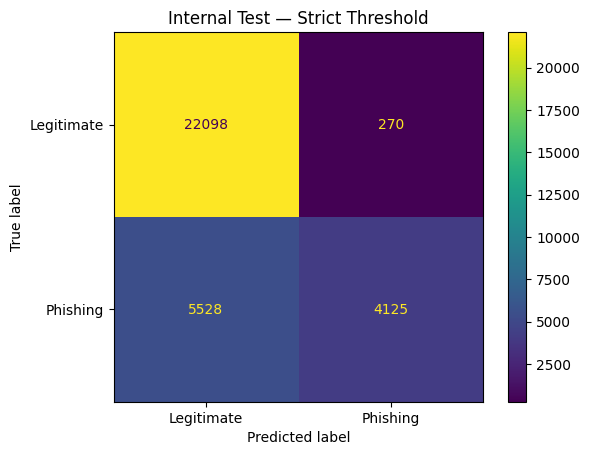

False positive: 270
False negative: 5528


In [ ]:
# 14. Classification report strict threshold
print(
    classification_report(
        test_df["label"],
        strict_result["prediction"],
        target_names=[
            "Legitimate",
            "Phishing"
        ],
        digits=4,
        zero_division=0
    )
)

cm = confusion_matrix(
    test_df["label"],
    strict_result["prediction"]
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Legitimate",
        "Phishing"
    ]
).plot()

plt.title("Internal Test — Strict Threshold")
plt.show()

false_positive = strict_result[
    (strict_result["label"] == 0)
    & (strict_result["prediction"] == 1)
].sort_values(
    "phishing_probability",
    ascending=False
)

false_negative = strict_result[
    (strict_result["label"] == 1)
    & (strict_result["prediction"] == 0)
].sort_values(
    "phishing_probability",
    ascending=True
)

false_positive.to_csv(
    OUTPUT_DIR / "false_positive.csv",
    index=False
)

false_negative.to_csv(
    OUTPUT_DIR / "false_negative.csv",
    index=False
)

print("False positive:", len(false_positive))
print("False negative:", len(false_negative))


## 10. External test PhishTank

External PhishTank hanya berisi kelas phishing. Karena itu, metrik yang digunakan adalah recall phishing.


In [ ]:

external_url_ds = external_ds.map(
    lambda urls, labels: urls
)

external_probability = (
    best_model
    .predict(
        external_url_ds,
        verbose=1
    )
    .reshape(-1)
)

external_balanced_prediction = (
    external_probability
    >= balanced_threshold
).astype("int8")

external_strict_prediction = (
    external_probability
    >= strict_threshold
).astype("int8")

external_metrics = {
    "rows": int(len(external_df)),
    "balanced_phishing_recall": float(
        external_balanced_prediction.mean()
    ),
    "strict_phishing_recall": float(
        external_strict_prediction.mean()
    ),
    "mean_probability": float(
        external_probability.mean()
    ),
    "median_probability": float(
        np.median(external_probability)
    ),
}

print(json.dumps(
    external_metrics,
    indent=2
))

with open(
    EXTERNAL_METRICS_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        external_metrics,
        file,
        indent=2
    )


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
{
  "rows": 10000,
  "balanced_phishing_recall": 0.6595,
  "strict_phishing_recall": 0.2947,
  "mean_probability": 0.636684000492096,
  "median_probability": 0.6922534704208374
}


## 11. Prediksi URL baru

Hasil terdiri dari:

- `legitimate`;
- `review` jika melewati balanced threshold tetapi belum melewati strict threshold;
- `phishing` jika melewati strict threshold.


In [ ]:
# 16. Fungsi prediksi URL baru
loaded_model = tf.keras.models.load_model(
    MODEL_PATH
)

with open(
    THRESHOLD_PATH,
    "r",
    encoding="utf-8"
) as file:
    loaded_thresholds = json.load(file)

CONTROL_PATTERN = re.compile(
    r"[\x00-\x1F\x7F]+"
)

def clean_url_for_prediction(value):
    value = str(value).strip()
    value = CONTROL_PATTERN.sub("", value)
    value = re.sub(
        r"(?i)^https?://",
        "",
        value
    )
    value = value.strip().lower()

    if len(value) > 1:
        value = value.rstrip("/")

    return value

def predict_urls(urls):
    if isinstance(urls, str):
        urls = [urls]

    original_urls = [
        str(url)
        for url in urls
    ]

    cleaned_urls = [
        clean_url_for_prediction(url)
        for url in original_urls
    ]

    probability = (
        loaded_model
        .predict(
            tf.constant(cleaned_urls),
            batch_size=256,
            verbose=0
        )
        .reshape(-1)
    )

    balanced = float(
        loaded_thresholds[
            "balanced_threshold"
        ]
    )

    strict = float(
        loaded_thresholds[
            "strict_threshold"
        ]
    )

    status = np.where(
        probability >= strict,
        "phishing",
        np.where(
            probability >= balanced,
            "review",
            "legitimate"
        )
    )

    binary_prediction = (
        probability >= strict
    ).astype("int8")

    return pd.DataFrame({
        "url": original_urls,
        "cleaned_url": cleaned_urls,
        "phishing_probability": probability,
        "balanced_threshold": balanced,
        "strict_threshold": strict,
        "prediction": binary_prediction,
        "status": status,
    })

example_urls = [
    "https://www.google.com/",
    "https://github.com/",
    "http://paypal-login-security.example.com/verify/account",
]

display(
    predict_urls(example_urls)
)


,url,cleaned_url,phishing_probability,balanced_threshold,strict_threshold,prediction,status
0,https://www.google.com/,www.google.com,0.280441,0.510421,0.867287,0,legitimate
1,https://github.com/,github.com,0.256555,0.510421,0.867287,0,legitimate
2,http://paypal-login-security.example.com/verif...,paypal-login-security.example.com/verify/account,0.899442,0.510421,0.867287,1,phishing


## 12. Prediksi file CSV

File input harus memiliki kolom `url`.


In [ ]:
def predict_csv(
    input_csv,
    output_csv=None,
    url_column="url"
):
    input_csv = Path(input_csv)

    if output_csv is None:
        output_csv = (
            OUTPUT_DIR
            / f"{input_csv.stem}_predictions.csv"
        )
    else:
        output_csv = Path(output_csv)

    data = pd.read_csv(
        input_csv,
        low_memory=False
    )

    if url_column not in data.columns:
        raise ValueError(
            f"Kolom '{url_column}' tidak ditemukan."
        )

    prediction = predict_urls(
        data[url_column]
        .fillna("")
        .astype(str)
        .tolist()
    )

    result = pd.concat(
        [
            data.reset_index(drop=True),
            prediction[
                [
                    "cleaned_url",
                    "phishing_probability",
                    "prediction",
                    "status",
                ]
            ],
        ],
        axis=1
    )

    result.to_csv(
        output_csv,
        index=False,
        encoding="utf-8"
    )

    print("Hasil tersimpan:", output_csv)

    return result

# Contoh:
# result = predict_csv(
#     "/content/drive/MyDrive/phishing_lstm_project/url_baru.csv"
# )
# display(result.head())


## Interpretasi

Nilai validation PR-AUC yang lebih tinggi daripada training PR-AUC tidak otomatis menunjukkan overfitting. Hal tersebut dapat terjadi karena dropout dan regularisasi aktif selama training, sedangkan tidak aktif saat validation.

Indikator overfitting yang lebih penting adalah:

- training loss terus turun;
- validation loss mulai naik;
- jarak performa training dan validation makin besar;
- performa internal tinggi tetapi external PhishTank rendah.

In [ ]:

import json
import shutil
import zipfile
from pathlib import Path

DEPLOY_DIR = PROJECT_DIR / "streamlit_phishing_app"
DEPLOY_MODEL_DIR = DEPLOY_DIR / "model"
DEPLOY_CONFIG_DIR = DEPLOY_DIR / ".streamlit"
DEPLOY_ZIP = PROJECT_DIR / "streamlit_phishing_app.zip"

if DEPLOY_DIR.exists():
    shutil.rmtree(DEPLOY_DIR)

DEPLOY_MODEL_DIR.mkdir(parents=True, exist_ok=True)
DEPLOY_CONFIG_DIR.mkdir(parents=True, exist_ok=True)

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Model belum ditemukan: {MODEL_PATH}. "
        "Jalankan training terlebih dahulu."
    )

if not THRESHOLD_PATH.exists():
    raise FileNotFoundError(
        f"Threshold belum ditemukan: {THRESHOLD_PATH}. "
        "Jalankan penentuan threshold terlebih dahulu."
    )

deployment_model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

DEPLOY_MODEL_PATH = DEPLOY_MODEL_DIR / "pure_lstm_model.keras"

deployment_model.save(
    DEPLOY_MODEL_PATH,
    include_optimizer=False
)

DEPLOY_THRESHOLD_PATH = DEPLOY_MODEL_DIR / "thresholds.json"
shutil.copy2(THRESHOLD_PATH, DEPLOY_THRESHOLD_PATH)

with open(THRESHOLD_PATH, "r", encoding="utf-8") as file:
    deployment_thresholds = json.load(file)

model_metadata = {
    "model_name": "pure_character_lstm",
    "framework": "TensorFlow/Keras",
    "tensorflow_version": tf.__version__,
    "input_type": "raw URL string",
    "label_mapping": {
        "0": "legitimate",
        "1": "phishing"
    },
    "preprocessing": {
        "remove_http_https_scheme": True,
        "lowercase": True,
        "remove_control_characters": True,
        "remove_trailing_slash": True
    },
    "balanced_threshold": float(
        deployment_thresholds["balanced_threshold"]
    ),
    "strict_threshold": float(
        deployment_thresholds["strict_threshold"]
    ),
    "default_threshold_mode": "strict"
}

with open(
    DEPLOY_MODEL_DIR / "model_metadata.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(model_metadata, file, indent=2)

app_code = 'import json\nimport re\nfrom pathlib import Path\n\nimport numpy as np\nimport pandas as pd\nimport streamlit as st\nimport tensorflow as tf\n\n\nAPP_DIR = Path(__file__).resolve().parent\nMODEL_DIR = APP_DIR / "model"\nMODEL_PATH = MODEL_DIR / "pure_lstm_model.keras"\nTHRESHOLD_PATH = MODEL_DIR / "thresholds.json"\n\nCONTROL_PATTERN = re.compile(r"[\\x00-\\x1F\\x7F]+")\n\n\ndef clean_url(value: str) -> str:\n    """Gunakan preprocessing yang sama seperti saat training."""\n    value = str(value).strip()\n    value = CONTROL_PATTERN.sub("", value)\n    value = re.sub(r"(?i)^https?://", "", value)\n    value = value.strip().lower()\n\n    if len(value) > 1:\n        value = value.rstrip("/")\n\n    return value\n\n\n@st.cache_resource\ndef load_artifacts():\n    if not MODEL_PATH.exists():\n        raise FileNotFoundError(f"Model tidak ditemukan: {MODEL_PATH}")\n\n    if not THRESHOLD_PATH.exists():\n        raise FileNotFoundError(f"Threshold tidak ditemukan: {THRESHOLD_PATH}")\n\n    model = tf.keras.models.load_model(\n        MODEL_PATH,\n        compile=False\n    )\n\n    with THRESHOLD_PATH.open("r", encoding="utf-8") as file:\n        thresholds = json.load(file)\n\n    return model, thresholds\n\n\ndef predict_urls(urls: list[str], threshold_mode: str = "strict") -> pd.DataFrame:\n    model, thresholds = load_artifacts()\n\n    original_urls = [str(url) for url in urls]\n    cleaned_urls = [clean_url(url) for url in original_urls]\n\n    probabilities = (\n        model.predict(\n            tf.constant(cleaned_urls),\n            batch_size=256,\n            verbose=0\n        )\n        .reshape(-1)\n    )\n\n    balanced_threshold = float(thresholds["balanced_threshold"])\n    strict_threshold = float(thresholds["strict_threshold"])\n\n    selected_threshold = (\n        strict_threshold\n        if threshold_mode == "strict"\n        else balanced_threshold\n    )\n\n    predictions = (\n        probabilities >= selected_threshold\n    ).astype(int)\n\n    status = np.where(\n        probabilities >= strict_threshold,\n        "Phishing",\n        np.where(\n            probabilities >= balanced_threshold,\n            "Perlu ditinjau",\n            "Legitimate"\n        )\n    )\n\n    return pd.DataFrame({\n        "URL": original_urls,\n        "Cleaned URL": cleaned_urls,\n        "Phishing Probability": probabilities,\n        "Threshold Used": selected_threshold,\n        "Prediction": predictions,\n        "Status": status,\n    })\n\n\nst.set_page_config(\n    page_title="Phishing URL Detector",\n    page_icon="🔗",\n    layout="wide"\n)\n\nst.title("🔗 Phishing URL Detector")\nst.caption(\n    "Deteksi URL menggunakan character-level LSTM. "\n    "Hasil merupakan prediksi model dan bukan jaminan keamanan mutlak."\n)\n\ntry:\n    model, thresholds = load_artifacts()\nexcept Exception as error:\n    st.error(\n        "Model gagal dimuat. Pastikan folder model berisi "\n        "`pure_lstm_model.keras` dan `thresholds.json`."\n    )\n    st.exception(error)\n    st.stop()\n\nwith st.sidebar:\n    st.header("Pengaturan")\n\n    threshold_mode = st.radio(\n        "Mode threshold",\n        options=["strict", "balanced"],\n        index=0,\n        format_func=lambda value: (\n            "Strict — lebih sedikit false positive"\n            if value == "strict"\n            else "Balanced — keseimbangan precision dan recall"\n        )\n    )\n\n    st.metric(\n        "Balanced threshold",\n        f"{float(thresholds[\'balanced_threshold\']):.4f}"\n    )\n\n    st.metric(\n        "Strict threshold",\n        f"{float(thresholds[\'strict_threshold\']):.4f}"\n    )\n\nsingle_tab, batch_tab = st.tabs([\n    "Periksa satu URL",\n    "Periksa file CSV"\n])\n\nwith single_tab:\n    url_input = st.text_input(\n        "Masukkan URL",\n        placeholder="https://contoh.com/login"\n    )\n\n    if st.button(\n        "Periksa URL",\n        type="primary",\n        use_container_width=True\n    ):\n        if not url_input.strip():\n            st.warning("Masukkan URL terlebih dahulu.")\n        else:\n            result = predict_urls(\n                [url_input],\n                threshold_mode=threshold_mode\n            )\n\n            probability = float(\n                result.loc[0, "Phishing Probability"]\n            )\n            status = str(result.loc[0, "Status"])\n\n            col1, col2 = st.columns(2)\n\n            with col1:\n                st.metric(\n                    "Probabilitas phishing",\n                    f"{probability:.2%}"\n                )\n\n            with col2:\n                st.metric("Status", status)\n\n            if status == "Phishing":\n                st.error(\n                    "URL terindikasi phishing. "\n                    "Jangan membuka atau memasukkan data pribadi."\n                )\n            elif status == "Perlu ditinjau":\n                st.warning(\n                    "URL berada di area abu-abu dan perlu "\n                    "diverifikasi lebih lanjut."\n                )\n            else:\n                st.success(\n                    "Model mengklasifikasikan URL sebagai legitimate."\n                )\n\n            st.dataframe(\n                result,\n                use_container_width=True,\n                hide_index=True\n            )\n\nwith batch_tab:\n    uploaded_file = st.file_uploader(\n        "Upload CSV dengan kolom `url`",\n        type=["csv"]\n    )\n\n    if uploaded_file is not None:\n        try:\n            uploaded_data = pd.read_csv(uploaded_file)\n        except Exception as error:\n            st.error("File CSV tidak dapat dibaca.")\n            st.exception(error)\n            st.stop()\n\n        if "url" not in uploaded_data.columns:\n            st.error("CSV harus memiliki kolom bernama `url`.")\n        else:\n            st.write(f"Jumlah URL: {len(uploaded_data):,}")\n\n            if st.button(\n                "Jalankan prediksi batch",\n                type="primary",\n                use_container_width=True\n            ):\n                with st.spinner("Melakukan prediksi..."):\n                    prediction_result = predict_urls(\n                        uploaded_data["url"]\n                        .fillna("")\n                        .astype(str)\n                        .tolist(),\n                        threshold_mode=threshold_mode\n                    )\n\n                    final_result = pd.concat(\n                        [\n                            uploaded_data.reset_index(drop=True),\n                            prediction_result[\n                                [\n                                    "Cleaned URL",\n                                    "Phishing Probability",\n                                    "Threshold Used",\n                                    "Prediction",\n                                    "Status",\n                                ]\n                            ],\n                        ],\n                        axis=1\n                    )\n\n                st.dataframe(\n                    final_result,\n                    use_container_width=True,\n                    hide_index=True\n                )\n\n                st.download_button(\n                    "Download hasil prediksi",\n                    data=final_result.to_csv(index=False).encode("utf-8"),\n                    file_name="phishing_url_predictions.csv",\n                    mime="text/csv",\n                    use_container_width=True\n                )\n'

(DEPLOY_DIR / "app.py").write_text(
    app_code,
    encoding="utf-8"
)

requirements = (
    "streamlit>=1.40,<2\n"
    f"tensorflow-cpu=={tf.__version__}\n"
    "pandas>=2,<3\n"
    "numpy>=1.26,<3\n"
)

(DEPLOY_DIR / "requirements.txt").write_text(
    requirements,
    encoding="utf-8"
)

config_toml = (
    "[server]\n"
    "headless = true\n\n"
    "[browser]\n"
    "gatherUsageStats = false\n"
)

(DEPLOY_CONFIG_DIR / "config.toml").write_text(
    config_toml,
    encoding="utf-8"
)

readme = f"""# Phishing URL Detector — Pure LSTM

## Menjalankan secara lokal

```bash
pip install -r requirements.txt
streamlit run app.py
```

## Deployment ke Streamlit Community Cloud

1. Upload seluruh isi folder ini ke repository GitHub.
2. Pilih `app.py` sebagai entrypoint.
3. Deploy aplikasi.

## Artefak model

- `model/pure_lstm_model.keras`
- `model/thresholds.json`
- `model/model_metadata.json`

TensorFlow training version: {tf.__version__}
"""

(DEPLOY_DIR / "README.md").write_text(
    readme,
    encoding="utf-8"
)

if DEPLOY_ZIP.exists():
    DEPLOY_ZIP.unlink()

with zipfile.ZipFile(
    DEPLOY_ZIP,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zip_file:
    for file_path in DEPLOY_DIR.rglob("*"):
        if file_path.is_file():
            zip_file.write(
                file_path,
                arcname=file_path.relative_to(DEPLOY_DIR)
            )

print("Paket Streamlit selesai dibuat.")
print("Folder :", DEPLOY_DIR)
print("ZIP    :", DEPLOY_ZIP)
print("Model  :", DEPLOY_MODEL_PATH)


Paket Streamlit selesai dibuat.
Folder : /content/drive/MyDrive/phishing_lstm_project/streamlit_phishing_app
ZIP    : /content/drive/MyDrive/phishing_lstm_project/streamlit_phishing_app.zip
Model  : /content/drive/MyDrive/phishing_lstm_project/streamlit_phishing_app/model/pure_lstm_model.keras


In [ ]:

import json

deployment_test_model = tf.keras.models.load_model(
    DEPLOY_MODEL_PATH,
    compile=False
)

with open(
    DEPLOY_THRESHOLD_PATH,
    "r",
    encoding="utf-8"
) as file:
    deployment_test_thresholds = json.load(file)

test_urls = [
    "www.google.com",
    "paypal-login-security.example.com/verify/account"
]

test_probabilities = (
    deployment_test_model.predict(
        tf.constant(test_urls),
        verbose=0
    )
    .reshape(-1)
)

deployment_test_result = pd.DataFrame({
    "url": test_urls,
    "phishing_probability": test_probabilities,
    "strict_prediction": (
        test_probabilities
        >= float(
            deployment_test_thresholds["strict_threshold"]
        )
    ).astype(int)
})

display(deployment_test_result)

print("ZIP siap deployment:", DEPLOY_ZIP)


,url,phishing_probability,strict_prediction
0,www.google.com,0.280441,0
1,paypal-login-security.example.com/verify/account,0.899442,1


ZIP siap deployment: /content/drive/MyDrive/phishing_lstm_project/streamlit_phishing_app.zip
